In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

In [ ]:
# Set the seed for reproducibility
np.random.seed(42)

In [ ]:
# Creamos nuestros datos artificiales (dos círculos concéntricos)
X, Y = make_circles(n_samples=500, factor=0.5, noise=0.05)

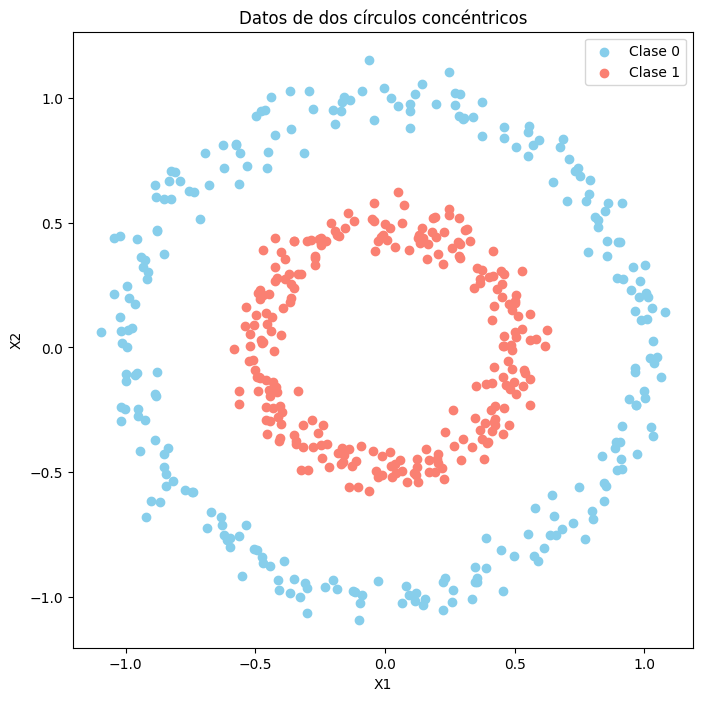

In [4]:
# Visualización de los datos generados
plt.figure(figsize=(8, 8))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Datos de dos círculos concéntricos")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,   # 20% prueba
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (400, 2)
Test : (100, 2)


In [6]:
import tensorflow as tf
from tensorflow import keras

modelo_reto = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

In [7]:
modelo_reto.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [8]:
historial = modelo_reto.fit(X_train, y_train, epochs=200, verbose=0)

In [9]:
loss, acc_reto = modelo_reto.evaluate(X_test, y_test, verbose=0)
print("Accuracy red profunda:", acc_reto)

Accuracy red profunda: 1.0


In [10]:
class ModeloWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X_test):
        return (self.model.predict(X_test, verbose=0) > 0.5).astype(int)

In [11]:
def plot_decision_boundary(model, X_test, y_test, title):
    h = 0.01
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,6))
    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(X[Y==0,0], X[Y==0,1], label="Clase 0")
    plt.scatter(X[Y==1,0], X[Y==1,1], label="Clase 1")

    plt.title(title)
    plt.legend()
    plt.show()

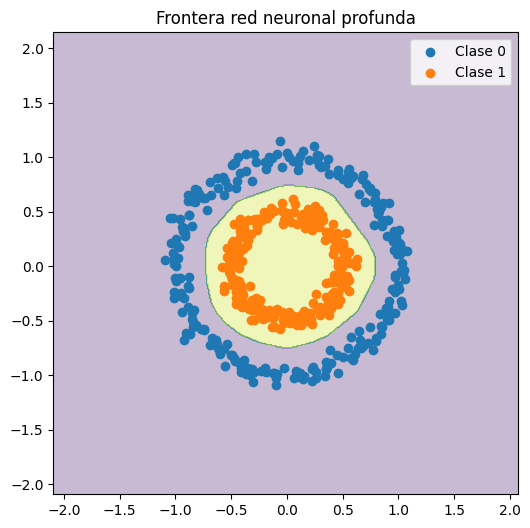

In [12]:
wrapper = ModeloWrapper(modelo_reto)
plot_decision_boundary(wrapper, X_test, y_test, "Frontera red neuronal profunda")